In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv


In [1]:
# =====================================================
# HEART DISEASE PREDICTION - MODEL TRAINING
# Kaggle Notebook
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve)
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries Loaded ✅")

Libraries Loaded ✅


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv')

# ── Column names fix karo ──────────────────────────
# thalch → thalach rename karo
# num → target rename karo (0=no disease, 1+=disease)
df = df.rename(columns={'thalch': 'thalach', 'num': 'target'})

# target ko binary banao (0=No Disease, 1=Disease)
df['target'] = (df['target'] > 0).astype(int)

# Sirf useful columns rakho
df = df[['age','sex','cp','trestbps','chol','fbs',
         'restecg','thalach','exang','oldpeak',
         'slope','ca','thal','target']]

# Text values ko numbers mein convert karo
df['sex']     = df['sex'].map({'Male':1, 'Female':0})
df['fbs']     = df['fbs'].map({True:1, False:0})
df['exang']   = df['exang'].map({True:1, False:0})
df['cp']      = df['cp'].map({
    'typical angina':0,
    'atypical angina':1,
    'non-anginal':2,
    'asymptomatic':3
})
df['restecg'] = df['restecg'].map({
    'normal':0,
    'st-t abnormality':1,
    'lv hypertrophy':2
})
df['slope']   = df['slope'].map({
    'upsloping':0,
    'flat':1,
    'downsloping':2
})
df['thal']    = df['thal'].map({
    'normal':0,
    'fixed defect':1,
    'reversible defect':2
})

# Missing values drop karo
df = df.dropna()

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nTarget Distribution:")
print(df['target'].value_counts())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Ready ✅")

Dataset Shape: (182, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Target Distribution:
target
0    133
1     49
Name: count, dtype: int64

First 3 rows:
   age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   63    1   0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1   67    1   3     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
3   37    1   2     130.0  250.0  0.0      0.0    187.0    0.0      3.5   

   slope   ca  thal  target  
0    2.0  0.0   1.0       0  
1    1.0  3.0   0.0       1  
3    2.0  0.0   0.0       0  

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Data Ready ✅


In [3]:
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print(df.head(2))

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Shape: (182, 14)
   age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   63    1   0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1   67    1   3     160.0  286.0  0.0      2.0    108.0    1.0      1.5   

   slope   ca  thal  target  
0    2.0  0.0   1.0       0  
1    1.0  3.0   0.0       1  


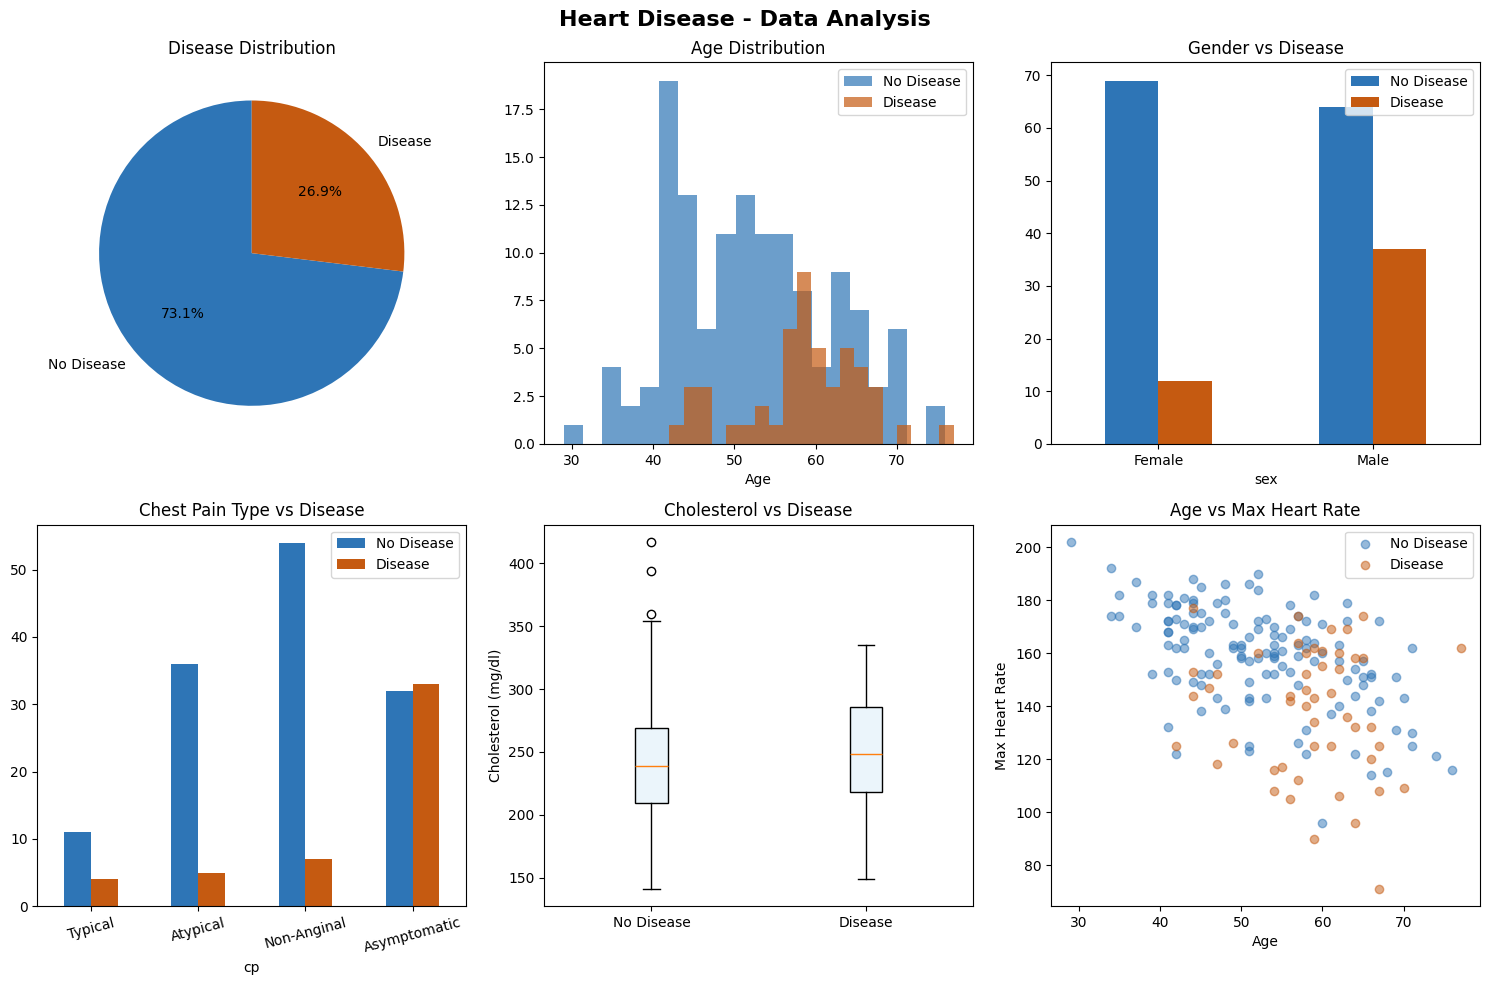

EDA Complete ✅


In [4]:
# =====================================================
# EDA — EXPLORATORY DATA ANALYSIS
# =====================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Heart Disease - Data Analysis', fontsize=16, fontweight='bold')

# 1. Target Distribution
axes[0,0].pie(df['target'].value_counts(),
              labels=['No Disease','Disease'],
              colors=['#2E75B6','#C55A11'],
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Disease Distribution')

# 2. Age Distribution
axes[0,1].hist(df[df['target']==0]['age'], alpha=0.7,
               color='#2E75B6', label='No Disease', bins=20)
axes[0,1].hist(df[df['target']==1]['age'], alpha=0.7,
               color='#C55A11', label='Disease', bins=20)
axes[0,1].set_title('Age Distribution')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# 3. Gender vs Disease
gender_disease = df.groupby(['sex','target']).size().unstack()
gender_disease.plot(kind='bar', ax=axes[0,2],
                    color=['#2E75B6','#C55A11'])
axes[0,2].set_title('Gender vs Disease')
axes[0,2].set_xticklabels(['Female','Male'], rotation=0)
axes[0,2].legend(['No Disease','Disease'])

# 4. Chest Pain vs Disease
cp_disease = df.groupby(['cp','target']).size().unstack()
cp_disease.plot(kind='bar', ax=axes[1,0],
                color=['#2E75B6','#C55A11'])
axes[1,0].set_title('Chest Pain Type vs Disease')
axes[1,0].set_xticklabels(
    ['Typical','Atypical','Non-Anginal','Asymptomatic'],
    rotation=15)
axes[1,0].legend(['No Disease','Disease'])

# 5. Cholesterol Distribution
axes[1,1].boxplot([df[df['target']==0]['chol'],
                   df[df['target']==1]['chol']],
                  labels=['No Disease','Disease'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#EBF5FB'))
axes[1,1].set_title('Cholesterol vs Disease')
axes[1,1].set_ylabel('Cholesterol (mg/dl)')

# 6. Max Heart Rate
axes[1,2].scatter(df[df['target']==0]['age'],
                  df[df['target']==0]['thalach'],
                  alpha=0.5, color='#2E75B6',
                  label='No Disease')
axes[1,2].scatter(df[df['target']==1]['age'],
                  df[df['target']==1]['thalach'],
                  alpha=0.5, color='#C55A11',
                  label='Disease')
axes[1,2].set_title('Age vs Max Heart Rate')
axes[1,2].set_xlabel('Age')
axes[1,2].set_ylabel('Max Heart Rate')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA Complete ✅")

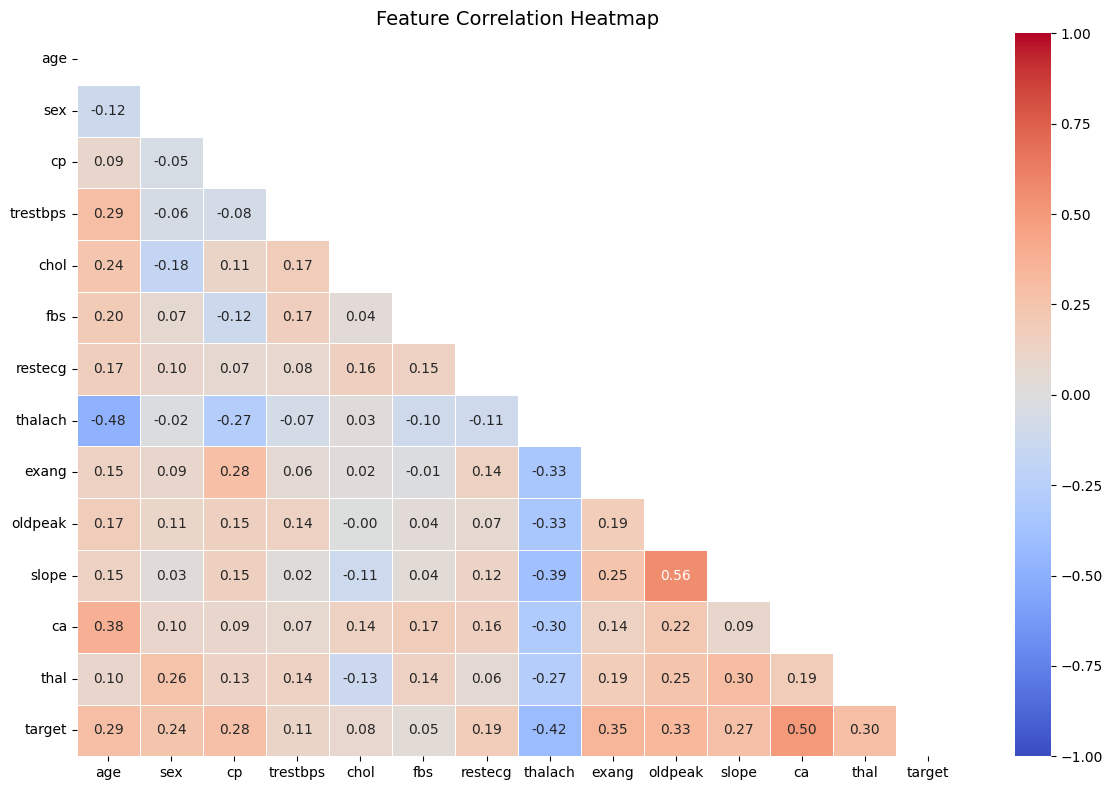

Correlation Heatmap Complete ✅


In [5]:
# =====================================================
# CORRELATION HEATMAP
# =====================================================

plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Correlation Heatmap Complete ✅")

In [6]:
# =====================================================
# PREPARE DATA
# =====================================================

X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("\nFeatures:", X.columns.tolist())
print("\nTarget Distribution:")
print(y.value_counts())

# Train Test Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # balanced split
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nData Preparation Complete ✅")

Features shape: (182, 13)
Target shape  : (182,)

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target Distribution:
target
0    133
1     49
Name: count, dtype: int64

Training samples : 145
Testing samples  : 37

Data Preparation Complete ✅


In [7]:
# =====================================================
# TRAIN MODEL
# =====================================================

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)
print("Model Training Complete ✅")

# Cross Validation
cv_scores = cross_val_score(model, X_train_scaled,
                             y_train, cv=5,
                             scoring='accuracy')
print(f"\nCross Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Std CV Accuracy : {cv_scores.std()*100:.2f}%")

Model Training Complete ✅

Cross Validation Scores: [0.79310345 0.86206897 0.72413793 0.82758621 0.93103448]
Mean CV Accuracy: 82.76%
Std CV Accuracy : 6.90%


MODEL PERFORMANCE
Accuracy  : 86.49%
ROC-AUC   : 0.8111

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.87      0.96      0.91        27
     Disease       0.86      0.60      0.71        10

    accuracy                           0.86        37
   macro avg       0.86      0.78      0.81        37
weighted avg       0.86      0.86      0.86        37



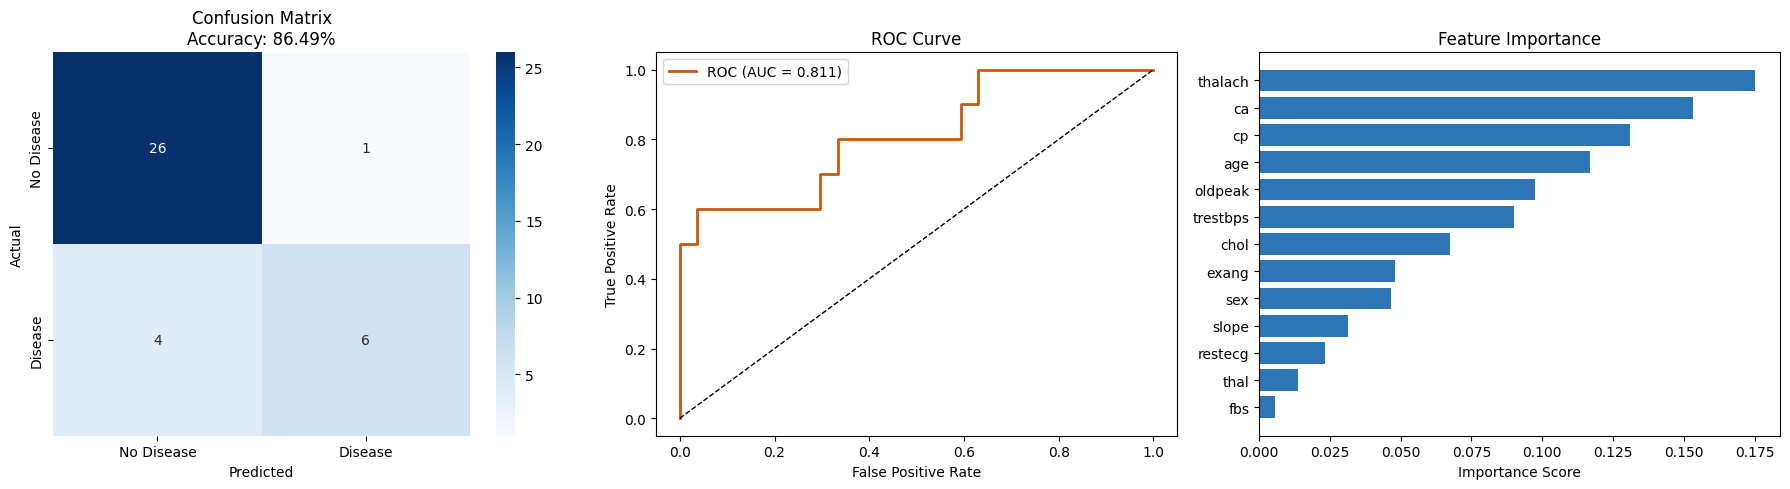


Evaluation Complete ✅


In [8]:
# =====================================================
# EVALUATE MODEL
# =====================================================

y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:,1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_prob)

print("="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Disease','Disease']))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix\nAccuracy: {accuracy*100:.2f}%')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#C55A11', lw=2,
             label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Feature Importance
feat_imp = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[2].barh(feat_imp['Feature'],
             feat_imp['Importance'],
             color='#2E75B6')
axes[2].set_title('Feature Importance')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150)
plt.show()

print("\nEvaluation Complete ✅")

In [9]:
# =====================================================
# SAVE MODEL + SCALER
# =====================================================

with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("heart_disease_model.pkl saved ✅")
print("scaler.pkl saved ✅")
print("\n" + "="*50)
print(f"FINAL ACCURACY : {accuracy*100:.2f}%")
print(f"FINAL ROC-AUC  : {roc_auc:.4f}")
print("="*50)
print("\nDownload these files:")
print("  1. heart_disease_model.pkl")
print("  2. scaler.pkl")
print("  3. notebook (File → Download)")

heart_disease_model.pkl saved ✅
scaler.pkl saved ✅

FINAL ACCURACY : 86.49%
FINAL ROC-AUC  : 0.8111

Download these files:
  1. heart_disease_model.pkl
  2. scaler.pkl
  3. notebook (File → Download)
